# SpecNet-ANN
This Jupyter Notebook defines, trains, and evaluates the `SpecNet-ANN` model, the first of the two `SpecNet` models that comprise this project.

## Library Imports

In [ ]:
# Library Imports
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Constants and Defines
INPUT_FILE      = "dataset.csv"
CHECKPOINT_DIR  = "checkpoints"
FINAL_MODEL     = "model_final.pth"

INPUTS   = ["gain_max_dB", "pm", "gbw"]
OUTPUTS  = ["w1", "w3"]

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.20
TEST_RATIO = 0.10

EPOCHS        = 300
BATCH_SIZE    = 32
LR            = 1e-3
CHECKPOINT_EVERY = 5
ACC_THRESHOLD = 0.1

SEED = 42

## Loading Dataset

In [64]:
# Prepare Checkpoint Directory and Load Data
torch.manual_seed(SEED)
np.random.seed(SEED)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

df = pd.read_csv(INPUT_FILE).sample(frac=1, random_state=SEED).reset_index(drop=True)

X = df[INPUTS].values.astype(np.float32)
y = df[OUTPUTS].values.astype(np.float32)

n = len(df)
n_train = int(n * TRAIN_RATIO)
n_val = int(n * VAL_RATIO)

# create data splits across ratios
X_train, y_train = X[:n_train], y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:], y[n_train+n_val:]


X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train)
X_val   = X_scaler.transform(X_val)
X_test  = X_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train)
y_val   = y_scaler.transform(y_val)
y_test  = y_scaler.transform(y_test)

print(f"Dataset split - train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

def to_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader = to_loader(X_val, y_val)
test_loader = to_loader(X_test, y_test)

Dataset split - train: 3080, val: 880, test: 440


## Model Class Definition

In [65]:
class SpecNetANN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # linear layers
        self.fc1 = nn.Linear(3, 128)
        self.fc2 = nn.Linear(128, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 2)

        # activation
        self.relu = nn.LeakyReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.fc5(x)

        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Training/Evaluation Function Definitions
### Measuring Accuracy
[need to explain how we're measuring accuracy here]

In [66]:
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_elements = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            
            total_loss += criterion(preds, yb).item() * len(xb)
            target_range = yb.max() - yb.min()
            
            if target_range > 0:
                threshold = ACC_THRESHOLD * target_range
            else:
                threshold = torch.tensor(ACC_THRESHOLD).to(device)
            
            total_correct += (torch.abs(preds - yb) <= threshold).sum().item()
            total_elements += yb.numel()
    return total_loss / len(loader.dataset), total_correct / total_elements * 100

In [67]:
# create model and associated objects
model = SpecNetANN().to(device)
optim = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode='min', factor=0.5, patience=10)

# intialize lists to store metrics
train_acc_history = []
val_acc_history = []
train_mse_history = []
val_mse_history = []

# training and hyperparam tuning loop
for epoch in range(0, EPOCHS):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optim.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optim.step()

    train_mse, train_acc = evaluate(train_loader)
    val_mse,   val_acc   = evaluate(val_loader)

    scheduler.step(val_mse)
    
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    train_mse_history.append(train_mse)
    val_mse_history.append(val_mse)

    # print stats
    if (epoch+1) % 10 == 0:
        print(f"Epoch: {epoch+1:>6} | Train Acc: {train_acc:>9.2f}% | Train MSE: {train_mse:>10.6f} "
              f"| Val Acc: {val_acc:>9.2f}% | Val MSE: {val_mse:>10.6f}")
    
    # save every 10th epoch
    if (epoch+1) % 10 and epoch+1 >= 100 == 0:
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optim.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_mse': train_mse,
            'val_mse': val_mse
        }, f'checkpoints/epoch_{epoch+1}_val_acc_{val_acc:.2f}.pt')


Epoch:     10 | Train Acc:     99.12% | Train MSE:   0.008669 | Val Acc:     98.86% | Val MSE:   0.008877
Epoch:     20 | Train Acc:     99.87% | Train MSE:   0.006556 | Val Acc:     99.72% | Val MSE:   0.007068
Epoch:     30 | Train Acc:     99.81% | Train MSE:   0.006187 | Val Acc:     99.60% | Val MSE:   0.007263
Epoch:     40 | Train Acc:     99.92% | Train MSE:   0.005346 | Val Acc:    100.00% | Val MSE:   0.005686
Epoch:     50 | Train Acc:     99.90% | Train MSE:   0.004357 | Val Acc:     99.83% | Val MSE:   0.004849
Epoch:     60 | Train Acc:    100.00% | Train MSE:   0.003331 | Val Acc:    100.00% | Val MSE:   0.004276
Epoch:     70 | Train Acc:    100.00% | Train MSE:   0.003498 | Val Acc:    100.00% | Val MSE:   0.004459
Epoch:     80 | Train Acc:    100.00% | Train MSE:   0.003611 | Val Acc:     99.89% | Val MSE:   0.004487
Epoch:     90 | Train Acc:    100.00% | Train MSE:   0.003173 | Val Acc:     99.89% | Val MSE:   0.004243
Epoch:    100 | Train Acc:    100.00% | Train 

<Figure size 1000x500 with 0 Axes>

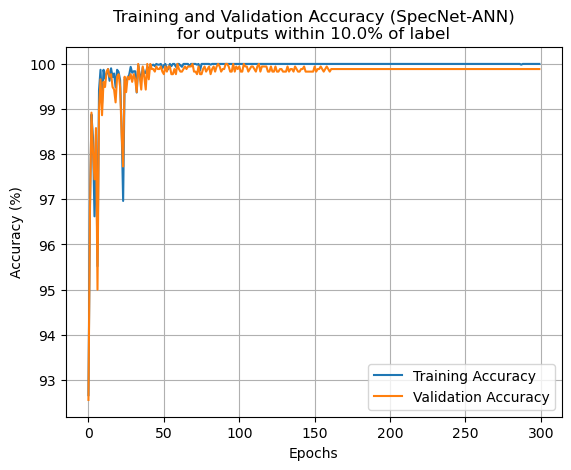

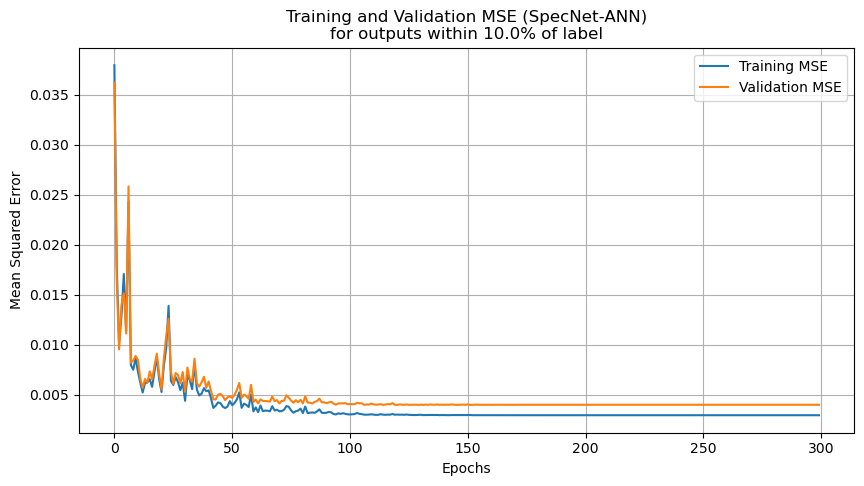

In [71]:
# plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.figure()
plt.plot(train_acc_history, label="Training Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy (SpecNet-ANN)\n"
         f"for outputs within {ACC_THRESHOLD*100}% of label")
plt.legend()
plt.grid(True)
# plt.show()
plt.savefig(f"accuracy_curve_{ACC_THRESHOLD}.png", dpi=300, bbox_inches="tight")

# plot training and validation MSE
plt.figure(figsize=(10, 5))
plt.plot(train_mse_history, label="Training MSE")
plt.plot(val_mse_history, label="Validation MSE")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Training and Validation MSE (SpecNet-ANN)\n"
         f"for outputs within {ACC_THRESHOLD*100}% of label")
plt.legend()
plt.grid(True)
# plt.show()
plt.savefig(f"mse_curve_{ACC_THRESHOLD}.png", dpi=300, bbox_inches="tight")

## Model on the Test Dataset

In [69]:
test_mse, test_acc = evaluate(test_loader)
print(f"Test Acc: {test_acc:.2f}% | Test MSE: {test_mse:.6f}")

Test Acc: 100.00% | Test MSE: 0.003247


## Miscellaneous Plots

<Figure size 1000x500 with 0 Axes>

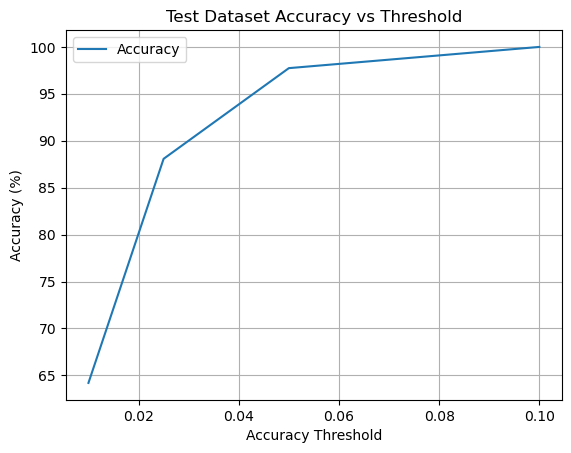

In [77]:
my_list_x = [0.01, 0.025, 0.05, 0.1]
my_list_y = [64.20, 88.07, 97.73, 99.99]

plt.figure(figsize=(10, 5))
plt.figure()
plt.plot(my_list_x, my_list_y, label="Accuracy")
plt.xlabel("Accuracy Threshold")
plt.ylabel("Accuracy (%)")
plt.title("Test Dataset Accuracy vs Threshold")
plt.legend()
plt.grid(True)
plt.savefig(f"threshold.png", dpi=300, bbox_inches="tight")